<h1 style="font-size:1.8em;font-weight:700;padding-bottom:10px;margin-bottom:4px;border-bottom:3px solid #2979ff">Workshop: Transfer Learning for Face Image Classification</h1>

Welcome! In this workshop you will train and inspect a simple image classifier built on top of a pretrained convolutional neural network.

## By the end of the workshop, you should be able to:
- load an image dataset with PyTorch
- explain the difference between training, validation, and benchmark data
- fine-tune a pretrained model for a new classification task
- evaluate a classifier with more than one metric
- inspect confident mistakes and discuss possible failure modes
- use Grad-CAM to visualize where the model is focusing

> **Important note about the labels**
> This dataset contains two face-image classes provided by the dataset creators. These labels are a simplification of a much more complex real-world concept. In this workshop, we treat the task as a **binary image classification exercise**, not as a reliable system for inferring gender identity from appearance.


<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;border-bottom:1px solid rgba(128,128,128,0.3)">Workshop roadmap</h2>

<h3 style="font-size:1.1em;font-weight:600;margin:12px 0 4px 0;padding-left:10px;border-left:3px solid rgba(128,128,128,0.4)">Part A - Core lab</h3>
1. Set up the environment  
2. Load and inspect the data  
3. Build dataloaders  
4. Train one pretrained model (**MobileNetV2**)  
5. Evaluate it on validation and benchmark data  
6. Inspect predictions, mistakes, and Grad-CAM explanations

<h3 style="font-size:1.1em;font-weight:600;margin:12px 0 4px 0;padding-left:10px;border-left:3px solid rgba(128,128,128,0.4)">Part B - Optional extension at the end</h3>
1. Run a few hyperparameter experiments  
2. Save results to TensorBoard  
3. Compare runs visually

Throughout the notebook, look for:
- **Checkpoint questions**: pause and discuss before moving on
- **Your turn** prompts: small things to try or interpret
- **Reflection prompts**: connect the results back to ML practice


<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;border-bottom:1px solid rgba(128,128,128,0.3)">How to use this notebook</h2>

> **Predict → Run → Reflect**
>
> Before running any cell marked **Your Turn** or **Checkpoint**:
> 1. **Predict** — write down what you expect to happen (output shape, curve direction, metric value)
> 2. **Run** — execute the cell
> 3. **Reflect** — was your prediction right? If not, why?
>
> This habit builds intuition faster than just running and reading.

<div style="padding:14px 18px;border-radius:6px;margin:10px 0;background:rgba(255,152,0,0.1);border-left:5px solid #fb8c00">
<h3 style="margin:0 0 6px 0">🎙️ Instructor explains</h3>
<b>Run the next cells. Don't read every line — just check that it finishes without errors.</b><br><br>
</div>

<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;border-bottom:1px solid rgba(128,128,128,0.3)">0. Setup</h2>

Run the next cell once. If your environment already has the required packages, it should finish quickly.


In [24]:
# Optional installs for workshop environments
%pip -q install gitpython grad-cam ipywidgets tensorboard


In [22]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shutil
import torch
import torch.nn as nn
from git import Repo
import shutil
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torch.utils.data import Subset

from torchvision.models import (
    mobilenet_v2, MobileNet_V2_Weights,
    resnet50, ResNet50_Weights,
    vit_b_16, ViT_B_16_Weights,
)
from torch.utils.tensorboard import SummaryWriter

warnings.filterwarnings("ignore")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print("Running in Colab:", IN_COLAB)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Running in Colab: True
Using device: cuda


<div style="padding:14px 18px;border-radius:6px;margin:10px 0;background:rgba(255,152,0,0.1);border-left:5px solid #fb8c00">
<h3 style="margin:0 0 6px 0">🎙️ Instructor explains</h3>
<b>These are your levers. We'll go through each one together.</b><br><br>
<ul style="margin:4px 0 0 0"><li><b>MODEL_NAME</b> — which pretrained backbone to use</li><li><b>FREEZE_BACKBONE</b> — whether to lock the pretrained weights</li><li><b>VALIDATION_SPLIT</b> — how much data to hold out for measuring generalisation</li></ul>
</div>

<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;border-bottom:1px solid rgba(128,128,128,0.3)">1. Workshop control panel</h2>

Edit this cell only if you want to change the **baseline run** for the whole notebook.

For the first pass through the workshop, it is usually best to keep the defaults and only experiment later.


> **After changing any setting**, re-run every cell from this point downward (Shift+Enter through each, or *Kernel → Restart & Run All*).

In [18]:
# =========================
# Workshop control panel
# =========================
IMG_SIZE = 224       # use 224 when MODEL_NAME = "vit_b_16"
BATCH_SIZE = 50
VALIDATION_SPLIT = 0.2

EPOCHS = 4
LEARNING_RATE = 1e-4
DROPOUT = 0.2

FREEZE_BACKBONE = True
UNFREEZE_LAST_BLOCK = False   # optional exploration
USE_DATA_AUGMENTATION = True

# Choose your backbone:  "mobilenet_v2"  |  "resnet50"  |  "vit_b_16"
MODEL_NAME = "mobilenet_v2"

NUM_WORKERS = 0               # set >0 locally if desired
SEED = 42

# For quick workshop reruns
SHOW_DATASET_EXAMPLES = 12
USE_INTERACTIVE = True        # set False to skip interactive widgets (faster reruns)
MOUNT_DRIVE = True            # set False to skip Drive mounting even in Colab
RANDOM_EXAMPLE_INDEX = None   # set a fixed int to always show the same example

<h4 style="color:#2196f3">Checkpoint question</h4>
Before you run the notebook, which settings above do you expect to have the largest effect on:
1. training speed  
2. overfitting  
3. final validation performance

Write down one prediction now. We will come back to it later.


## 2. Get the data

This notebook expects the following dataset structure:

- `faces/train/female`
- `faces/train/male`
- `faces/benchmark/female`
- `faces/benchmark/male`

By default, the next cell clones the public repository used in the original notebook.

<h4 style="color:#2196f3">Think before you run</h4>
Why might we want a **benchmark** split that stays untouched until the end?


In [19]:
if IN_COLAB and MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/gdrive/')
    DATA_PATH = Path('/content/gdrive/MyDrive/cvlab_workshop')
    DATA_PATH.mkdir(parents=True, exist_ok=True)
elif IN_COLAB:
    DATA_PATH = Path("/content/drive/MyDrive/cvlab_workshop")
else:
    DATA_PATH = Path.cwd() / "data"

print("Results and data will be saved to:", DATA_PATH)


Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).
Results and data will be saved to: /content/gdrive/MyDrive/cvlab_workshop


In [20]:
FORCE_RECLONE = True

DATA_PATH.mkdir(parents=True, exist_ok=True)

FACES_PATH = DATA_PATH / "faces"
TRAIN_PATH = FACES_PATH / "train"
BENCHMARK_PATH = FACES_PATH / "benchmark"

if FORCE_RECLONE and FACES_PATH.exists():
    shutil.rmtree(FACES_PATH)

print("Data path:", DATA_PATH)

if not FACES_PATH.exists():
    print("Cloning dataset...")
    Repo.clone_from("https://github.com/susuter/faces_red.git", FACES_PATH)

    # Original repo layout: female/, male/, benchmark/
    female_path = FACES_PATH / "female"
    male_path = FACES_PATH / "male"
    TRAIN_PATH.mkdir(parents=True, exist_ok=True)

    if female_path.exists():
        shutil.move(str(female_path), str(TRAIN_PATH / "female"))
    if male_path.exists():
        shutil.move(str(male_path), str(TRAIN_PATH / "male"))
else:
    print("Dataset already available at:", FACES_PATH)

assert TRAIN_PATH.exists(), f"Training path not found: {TRAIN_PATH}"
assert BENCHMARK_PATH.exists(), f"Benchmark path not found: {BENCHMARK_PATH}"

print("Training path:", TRAIN_PATH)
print("Benchmark path:", BENCHMARK_PATH)


Data path: /content/gdrive/MyDrive/cvlab_workshop
Cloning dataset...


KeyboardInterrupt: 

<div style="padding:14px 18px;border-radius:6px;margin:10px 0;background:rgba(255,152,0,0.1);border-left:5px solid #fb8c00">
<h3 style="margin:0 0 6px 0">🎙️ Instructor explains</h3>
<b>Two separate pipelines — one for your eyes, one for the model.</b><br><br>
<ul style="margin:4px 0 0 0"><li>Display pipeline: keeps colours natural so you can see the image</li><li>Model pipeline: applies ImageNet mean/std normalisation — pixels are no longer in [0, 1]</li><li>Same underlying image, two different views</li></ul>
</div>

<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;border-bottom:1px solid rgba(128,128,128,0.3)">3. Data transforms</h2>

We separate two transform pipelines:
- a **display transform** for visualization
- a **model transform** for training and evaluation

This keeps the notebook easier to understand because normalized tensors are great for the model, but not very nice to display directly.

<h3 style="font-size:1.1em;font-weight:600;margin:12px 0 4px 0;padding-left:10px;border-left:3px solid rgba(128,128,128,0.4)">How data normalization works</h3>

```
Normalized image tensor: torch.Size([3, H, W])
                          ─  ───  ───
                          │   │    └─ width
                          │   └────── height
                          └────────── channels
```

Before feeding data into a model, we often **normalize** it so that values are on a consistent scale. This improves numerical stability and helps models learn more effectively.

A common approach is to normalize each channel by:
- subtracting a mean
- dividing by a standard deviation

In general form:

```
x_norm = (x - mean) / std
```

For many pretrained computer vision models (e.g. trained on ImageNet), fixed statistics are used:

- mean = (0.485, 0.456, 0.406)
- std  = (0.229, 0.224, 0.225)

This ensures that input data matches the distribution the model was originally trained on.

In [ ]:

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

display_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

if USE_DATA_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])
else:
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])


<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;border-bottom:1px solid rgba(128,128,128,0.3)">4. Load datasets</h2>

We load the same image files more than once:
- once with the **display** transform
- once with the **training/evaluation** transforms

This is a very practical pattern in workshops because it avoids a common beginner problem: plotting normalized images and wondering why they look strange.


<h3 style="font-size:1.1em;font-weight:600;margin:12px 0 4px 0;padding-left:10px;border-left:3px solid rgba(128,128,128,0.4)">Dataset vs DataLoader — what is the difference?</h3>

**`Dataset`** (`ImageFolder`) is a directory-aware container. Calling `dataset[i]` reads one image from disk, applies the transform, and returns a `(tensor, label)` pair. It does nothing on its own — it just knows how to serve one sample at a time.

**`DataLoader`** wraps a Dataset and adds the machinery needed for training:
- groups samples into **batches** (`BATCH_SIZE` images at once)
- **shuffles** the order each epoch so the model does not memorise the sequence
- loads samples in **parallel** (`num_workers`) to keep the GPU busy

```
ImageFolder  →  DataLoader  →  model
(one image)     (batch of N)   (sees N images per step)
```

That is why we have both: `full_train_display` (Dataset, for browsing) and `train_loader` (DataLoader, for training).


In [ ]:

full_train_display = datasets.ImageFolder(TRAIN_PATH, transform=display_transform)
full_train_model   = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
full_train_eval    = datasets.ImageFolder(TRAIN_PATH, transform=eval_transform)
benchmark_display  = datasets.ImageFolder(BENCHMARK_PATH, transform=display_transform)
benchmark_model    = datasets.ImageFolder(BENCHMARK_PATH, transform=eval_transform)

class_names = full_train_model.classes
num_classes  = len(class_names)

assert full_train_display.classes == full_train_model.classes == benchmark_model.classes

# Person-aware split — same person must not appear in both train and validation sets.
# Person identity is encoded in the filename stem (e.g. "Ai_Sugiyama" from "Ai_Sugiyama_0001.jpg").
samples    = full_train_model.samples  # list of (path, label)
persons    = np.array(['_'.join(Path(p).stem.split('_')[:-1]) for p, _ in samples])
labels_arr = np.array([lbl for _, lbl in samples])

rng = np.random.default_rng(SEED)
train_idx, val_idx = [], []

for label in np.unique(labels_arr):
    indices = np.where(labels_arr == label)[0]
    unique_persons = np.unique(persons[indices])
    rng.shuffle(unique_persons)
    n_val_persons = max(1, round(len(unique_persons) * VALIDATION_SPLIT))
    val_persons = set(unique_persons[:n_val_persons])
    for i in indices:
        (val_idx if persons[i] in val_persons else train_idx).append(i)

train_idx = np.array(train_idx)
val_idx   = np.array(val_idx)

train_model_ds   = Subset(full_train_model, train_idx)
val_model_ds     = Subset(full_train_model, val_idx)
val_eval_ds      = Subset(full_train_eval,  val_idx)
train_display_ds = Subset(full_train_display, train_idx)
val_display_ds   = Subset(full_train_display, val_idx)

n_train = len(train_idx)
n_val   = len(val_idx)

train_loader     = DataLoader(train_model_ds,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader       = DataLoader(val_eval_ds,      batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
benchmark_loader = DataLoader(benchmark_model,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train: {n_train} images | Val: {n_val} images | Benchmark: {len(benchmark_model)} images")
print(f"Classes: {class_names}")

Train: 3764 images | Val: 964 images | Benchmark: 200 images
Classes: ['female', 'male']


<div style="padding:14px 18px;border-radius:6px;margin:10px 0;background:rgba(76,175,80,0.1);border-left:5px solid #43a047">
<h3 style="margin:0 0 6px 0">🧪 Your turn!</h3>
<b>Before writing a single line of training code — explore the data.</b><br><br>
<ul style="margin:4px 0 0 0"><li>How many images are there per class? Is it balanced?</li><li>Browse 5–10 images. Do they all look like clean face photos?</li><li>What could go wrong if the classes were very imbalanced?</li></ul>
</div>

<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;border-bottom:1px solid rgba(128,128,128,0.3)">5. Inspect the data</h2>

Before training any model, we should first understand the dataset.

<h3 style="font-size:1.1em;font-weight:600;margin:12px 0 4px 0;padding-left:10px;border-left:3px solid rgba(128,128,128,0.4)">5.1 Class balance</h3>


<h3 style="font-size:1.1em;font-weight:600;margin:12px 0 4px 0;padding-left:10px;border-left:3px solid rgba(128,128,128,0.4)">5.1 Single image — shape & augmentations</h3>

The cell below loads one image using both transform pipelines and prints the resulting tensor shape.

**Questions**
- What does each dimension of the tensor shape `(C, H, W)` represent?
- Why do the pixel values differ between the display and model tensors for the same image?


Class          : female
Display tensor : torch.Size([3, 224, 224])  — (C, H, W), values in [0, 1]
Model tensor   : torch.Size([3, 224, 224])  — (C, H, W), ImageNet-normalized


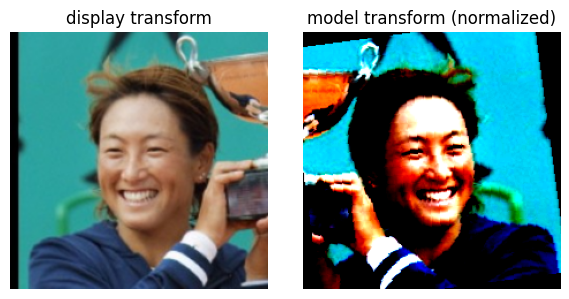

In [ ]:
idx = 10
img_display, label = full_train_display[idx]
img_model, _       = full_train_model[idx]

print(f"Class          : {class_names[label]}")
print(f"Display tensor : {img_display.shape}  — (C, H, W), values in [0, 1]")
print(f"Model tensor   : {img_model.shape}  — (C, H, W), ImageNet-normalized")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img_display.permute(1, 2, 0))
axes[0].set_title("display transform")
axes[0].axis("off")
axes[1].imshow(img_model.permute(1, 2, 0).clamp(0, 1))
axes[1].set_title("model transform (normalized)")
axes[1].axis("off")
plt.tight_layout()
plt.show()


In [ ]:

from collections import Counter

train_targets = [full_train_model.samples[i][1] for i in range(len(full_train_model))]
benchmark_targets = [benchmark_model.samples[i][1] for i in range(len(benchmark_model))]

train_counts = Counter(train_targets)
benchmark_counts = Counter(benchmark_targets)

summary_df = pd.DataFrame({
    "class": class_names,
    "train_count": [train_counts[i] for i in range(num_classes)],
    "benchmark_count": [benchmark_counts[i] for i in range(num_classes)],
})
summary_df


,class,train_count,benchmark_count
0,female,1950,100
1,male,2778,100


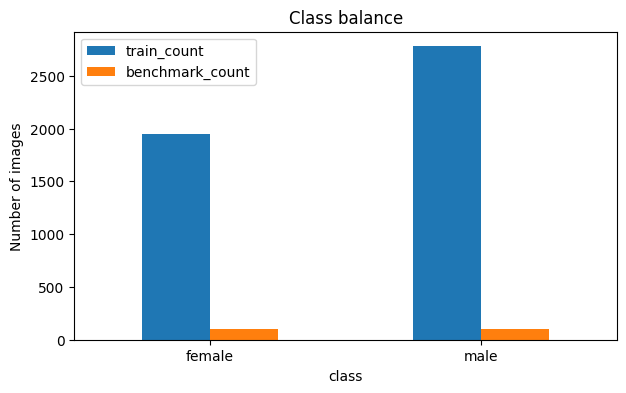

In [ ]:

summary_df.set_index("class").plot(kind="bar", figsize=(7,4))
plt.title("Class balance")
plt.ylabel("Number of images")
plt.xticks(rotation=0)
plt.show()


<h4 style="color:#2196f3">Checkpoint questions</h4>

- Are the classes balanced?
- How could the models be impacted by this? 
- If the classes were strongly imbalanced, would accuracy alone still be enough?
- Which other metric(s) would you want to inspect?


<h3 style="font-size:1.1em;font-weight:600;margin:12px 0 4px 0;padding-left:10px;border-left:3px solid rgba(128,128,128,0.4)">5.2 Browse some examples</h3>

Use the widget below to look at a few training images.


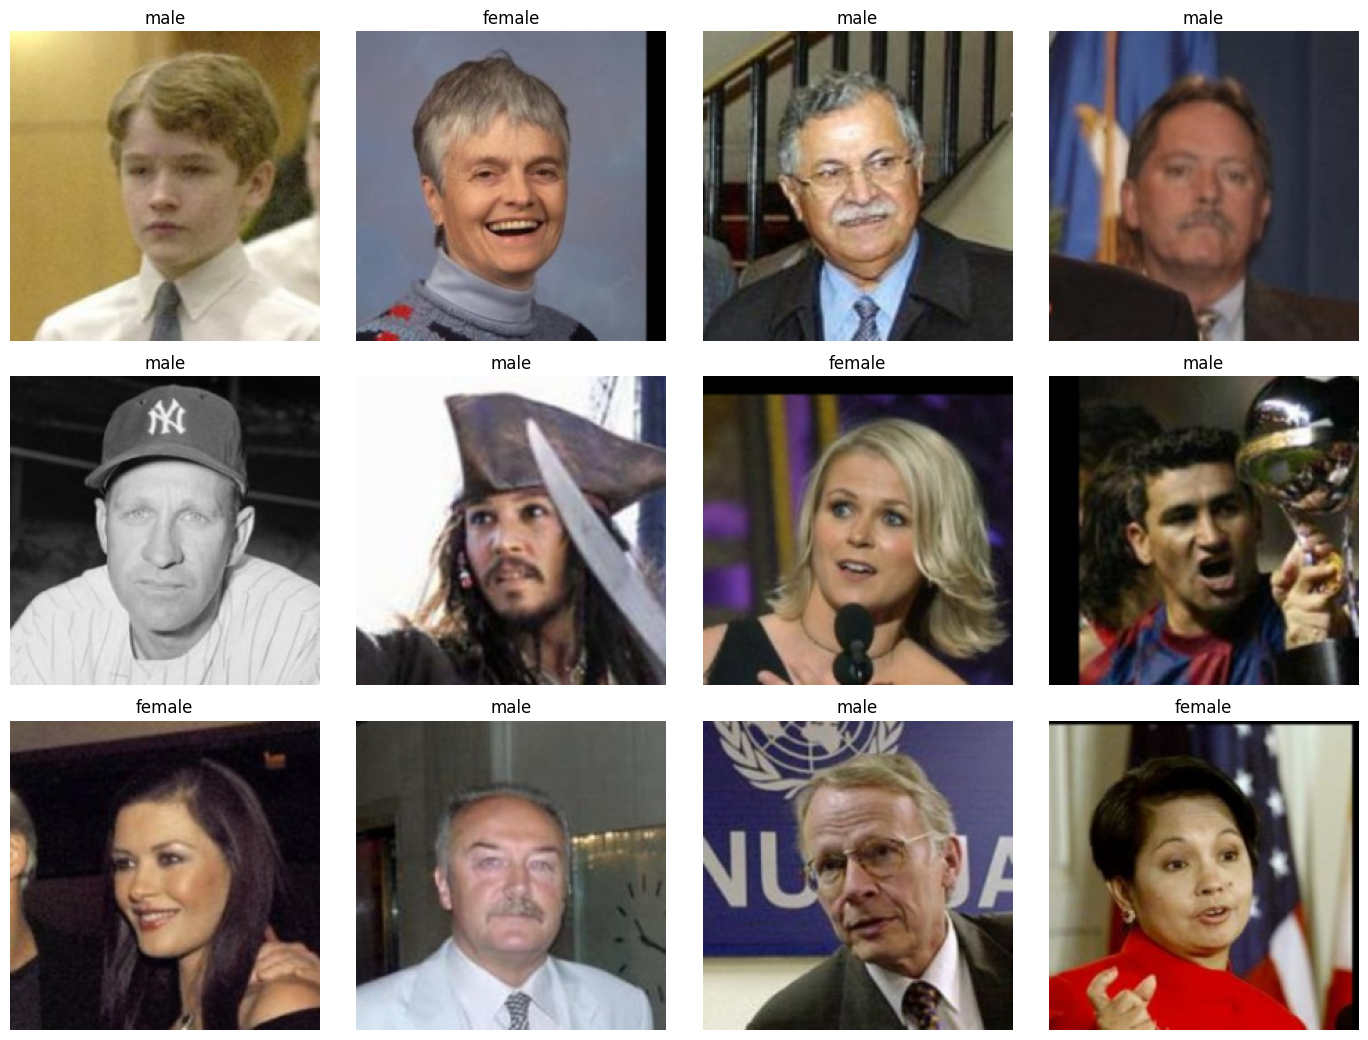

In [ ]:

import ipywidgets as widgets
from IPython.display import display

def show_example_grid(dataset, class_names, n=12, seed=SEED):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(dataset), size=min(n, len(dataset)), replace=False)
    cols = 4
    rows = int(np.ceil(len(indices) / cols))
    plt.figure(figsize=(3.5 * cols, 3.5 * rows))
    for i, idx in enumerate(indices, 1):
        img, label = dataset[idx]
        img = img.permute(1, 2, 0).numpy()
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(class_names[label])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_example_grid(full_train_display, class_names, n=SHOW_DATASET_EXAMPLES)


In [ ]:
def browse_dataset(dataset, class_names):
    def _show(i=0):
        img, label = dataset[i]
        img = img.permute(1, 2, 0).numpy()
        plt.figure(figsize=(4,4))
        plt.imshow(img)
        plt.title(f"Index: {i} | Label: {class_names[label]}")
        plt.axis("off")

    slider = widgets.IntSlider(
        value=0, min=0, max=len(dataset)-1, step=1, description="sample"
    )
    widgets.interact(_show, i=slider)

if USE_INTERACTIVE:
    browse_dataset(full_train_display, class_names)
else:
    show_example_grid(full_train_display, class_names)

interactive(children=(IntSlider(value=0, description='sample', max=4727), Output()), _dom_classes=('widget-int…

<div style="padding:14px 18px;border-radius:6px;margin:10px 0;background:rgba(76,175,80,0.1);border-left:5px solid #43a047">
<h3 style="margin:0 0 6px 0">🧪 Your turn!</h3>
<b>Run these cells and check the output makes sense.</b><br><br>
<ul style="margin:4px 0 0 0"><li>What is the shape of one batch? Does it match what you set in the control panel?</li><li>Do the class labels in the batch look right?</li></ul>
</div>

<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;border-bottom:1px solid rgba(128,128,128,0.3)">6. Sanity checks before training</h2>

These checks are simple but extremely valuable. They help you verify that:
- the dataloaders work
- labels are correct
- the model will receive the shape we expect

A lot of training bugs can be caught right here.


In [ ]:

images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Label ids in batch:", labels[:10].tolist())
print("Class mapping:", full_train_model.class_to_idx)


Batch image shape: torch.Size([50, 3, 224, 224])
Batch label shape: torch.Size([50])
Label ids in batch: [0, 1, 0, 1, 0, 0, 1, 1, 1, 0]
Class mapping: {'female': 0, 'male': 1}


The output above should look like:

```
Batch image shape: torch.Size([16, 3, 224, 224])
                             ──  ─  ───  ───
                             │   │   │    └─ image width  (px)
                             │   │   └────── image height (px)
                             │   └────────── colour channels (R, G, B)
                             └────────────── batch size
```

Every time the model processes one batch it sees `BATCH_SIZE` images simultaneously, each represented as a 3-D tensor of shape `(C, H, W)`.


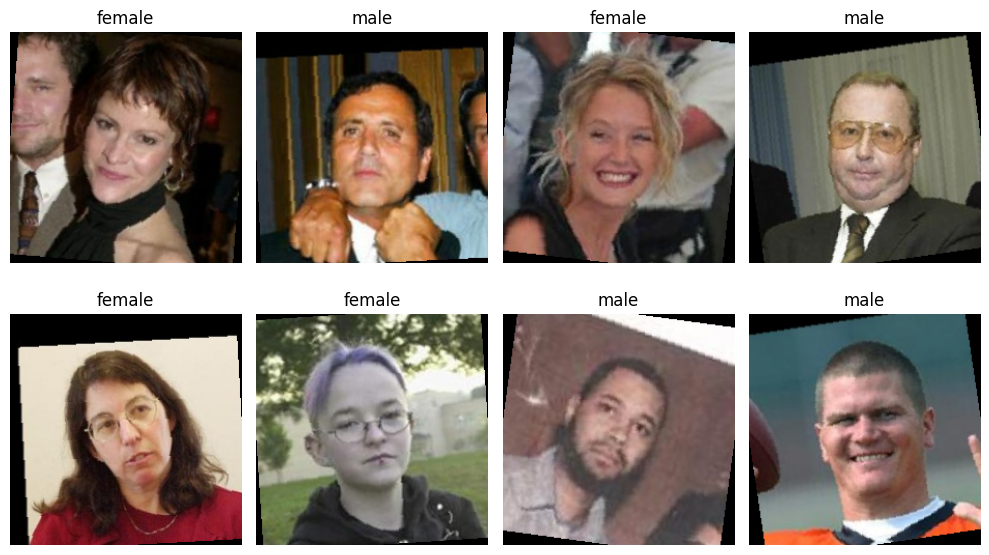

In [ ]:

# Visualize a batch after undoing normalization
def denormalize(img_tensor, mean=imagenet_mean, std=imagenet_std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return img_tensor * std + mean

plt.figure(figsize=(10, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).clamp(0, 1).numpy()
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()


<div style="padding:14px 18px;border-radius:6px;margin:10px 0;background:rgba(255,152,0,0.1);border-left:5px solid #fb8c00">
<h3 style="margin:0 0 6px 0">🎙️ Instructor explains</h3>
<b>A pretrained CNN is split into two parts.</b><br><br>
<ul style="margin:4px 0 0 0"><li><b>Backbone</b> — a deep feature extractor trained on millions of ImageNet images, kept frozen</li><li><b>Classifier head</b> — a tiny linear layer we train from scratch on our data</li><li>We borrow the knowledge, add a small learnable layer on top</li></ul>
</div>

<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;border-bottom:1px solid rgba(128,128,128,0.3)">7. Build the model</h2>

Choose a pretrained backbone by setting `MODEL_NAME` in the control panel:

| `MODEL_NAME` | Architecture | Trainable params (frozen) | Notes |
|---|---|---|---|
| `"mobilenet_v2"` | MobileNetV2 | ~1.2 M | Fast; good default for short sessions |
| `"resnet50"` | ResNet-50 | ~2.1 M | Classic CNN; stronger baseline |
| `"vit_b_16"` | ViT-B/16 | ~0.7 M | Transformer; set `IMG_SIZE = 224` |

All three are pretrained on ImageNet. The original classifier head is replaced
with a dropout + linear layer for our binary task.

<h3 style="font-size:1.1em;font-weight:600;margin:12px 0 4px 0;padding-left:10px;border-left:3px solid rgba(128,128,128,0.4)">Backbone vs. classifier head</h3>

A pretrained CNN can be split into two parts:

```
 Input image
      │
      ▼
┌─────────────────────────────┐
│        BACKBONE             │  ← frozen (pretrained on ImageNet)
│  convolutional / attention  │
│  layers that extract visual │
│  features (edges, textures, │
│  shapes, …)                 │
└─────────────┬───────────────┘
              │  feature vector  (e.g. 1280-d for MobileNetV2)
              ▼
┌─────────────────────────────┐
│     CLASSIFIER HEAD         │  ← trained by us
│  Dropout  →  Linear(2)      │
└─────────────┬───────────────┘
              │
              ▼
       class scores (2)
```

**Backbone** — the large body of the network. It was trained on 1.2 M ImageNet images and has already learned to recognise low-level features (edges, textures) and high-level patterns (eyes, fur, wheels …). We *reuse* these weights instead of learning from scratch.

**Classifier head** — a small layer we attach on top. It takes the compact feature vector produced by the backbone and maps it to our two classes. Because it is randomly initialised, this is the part that actually needs to be trained.

> **Freezing** the backbone means its weights are fixed during training — only the head is updated. This is fast and avoids overfitting when the dataset is small. `UNFREEZE_LAST_BLOCK = True` lets the final backbone block adapt too, which can squeeze out a bit more accuracy at the cost of longer training.


In [ ]:
def build_model(model_name=MODEL_NAME, num_classes=2, dropout=0.2,
                freeze_backbone=True, unfreeze_last_block=False):
    if model_name == "mobilenet_v2":
        base = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V2)
        if freeze_backbone:
            for param in base.features.parameters():
                param.requires_grad = False
        if unfreeze_last_block:
            for param in base.features[-1].parameters():
                param.requires_grad = True
        in_features = base.classifier[1].in_features
        base.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes),
        )

    elif model_name == "resnet50":
        base = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        if freeze_backbone:
            for name, param in base.named_parameters():
                if not name.startswith("fc"):
                    param.requires_grad = False
        if unfreeze_last_block:
            for param in base.layer4.parameters():
                param.requires_grad = True
        in_features = base.fc.in_features
        base.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes),
        )

    elif model_name == "vit_b_16":
        base = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for name, param in base.named_parameters():
                if not name.startswith("heads"):
                    param.requires_grad = False
        if unfreeze_last_block:
            for param in base.encoder.layers[-1].parameters():
                param.requires_grad = True
        in_features = base.heads.head.in_features
        base.heads.head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes),
        )

    else:
        raise ValueError(
            f"Unknown MODEL_NAME {model_name!r}. "
            "Choose 'mobilenet_v2', 'resnet50', or 'vit_b_16'."
        )

    return base

model = build_model(
    model_name=MODEL_NAME,
    num_classes=num_classes,
    dropout=DROPOUT,
    freeze_backbone=FREEZE_BACKBONE,
    unfreeze_last_block=UNFREEZE_LAST_BLOCK,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Backbone:           {MODEL_NAME}")
print(f"Freeze backbone:    {FREEZE_BACKBONE}")
print(f"Unfreeze last block: {UNFREEZE_LAST_BLOCK}")
print(f"Dropout:            {DROPOUT}")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

<h4 style="color:#2196f3">Checkpoint questions</h4>

- What does it mean to **freeze** the backbone?
- Why might we prefer fewer trainable parameters in a short workshop?
- What do you predict will happen if we unfreeze more layers?


In [ ]:

with torch.no_grad():
    logits = model(images.to(device))
    
print("Model output shape:", logits.shape)
print("Expected shape:    ", (images.shape[0], num_classes))


<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;border-bottom:1px solid rgba(128,128,128,0.3)">8. Training utilities</h2>

The next cell defines helper functions for:
- one training epoch
- one evaluation pass
- plotting learning curves
- optional TensorBoard logging

You do not need to edit it during the workshop, but it is worth skimming once so you know where the metrics come from.


In [ ]:
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns


def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Run one full pass over the training set and update model weights."""
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in tqdm(dataloader, leave=False, desc="Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    return {
        "loss": running_loss / running_total,
        "accuracy": running_correct / running_total,
    }


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    """Evaluate the model on a dataset without updating weights. Returns loss and classification metrics."""
    model.eval()
    running_loss = 0.0
    running_total = 0
    all_labels = []
    all_preds = []

    for images, labels in tqdm(dataloader, leave=False, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        preds = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        running_total += labels.size(0)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    labels_np = np.array(all_labels)
    preds_np = np.array(all_preds)

    return {
        "loss": running_loss / running_total,
        "accuracy": accuracy_score(labels_np, preds_np),
        "precision": precision_score(labels_np, preds_np, average="weighted", zero_division=0),
        "recall": recall_score(labels_np, preds_np, average="weighted", zero_division=0),
        "f1": f1_score(labels_np, preds_np, average="weighted", zero_division=0),
        "labels": labels_np,
        "preds": preds_np,
    }


def log_metrics_to_tensorboard(writer, metrics, split, epoch):
    """Write loss and classification metrics to TensorBoard for a given split and epoch."""
    for metric_name in ["loss", "accuracy", "precision", "recall", "f1"]:
        if metric_name in metrics:
            writer.add_scalar(f"{split}/{metric_name}", float(metrics[metric_name]), epoch)


def fit(model, train_loader, val_loader, criterion, optimizer, device, epochs, writer=None):
    """Run the full training loop for the given number of epochs, logging metrics after each one."""
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
        "val_precision": [], "val_recall": [], "val_f1": []
    }

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())

    if writer is not None:
        writer.add_scalar("model/trainable_parameters", trainable_params, 0)
        writer.add_scalar("model/total_parameters", total_params, 0)

    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch}/{epochs}")
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_metrics = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_precision"].append(val_metrics["precision"])
        history["val_recall"].append(val_metrics["recall"])
        history["val_f1"].append(val_metrics["f1"])

        print(
            f"train_loss={train_metrics['loss']:.4f} | train_acc={train_metrics['accuracy']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['accuracy']:.4f} | "
            f"val_f1={val_metrics['f1']:.4f}"
        )

        if writer is not None:
            log_metrics_to_tensorboard(writer, train_metrics, "train", epoch)
            log_metrics_to_tensorboard(writer, val_metrics, "validation", epoch)
            writer.add_scalar("optimizer/learning_rate", optimizer.param_groups[0]["lr"], epoch)

    return history


def plot_history(history):
    """Plot training vs validation loss, accuracy, and validation precision/recall/F1 over epochs."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="validation")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="train")
    axes[1].plot(history["val_acc"], label="validation")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    axes[2].plot(history["val_precision"], label="precision")
    axes[2].plot(history["val_recall"], label="recall")
    axes[2].plot(history["val_f1"], label="f1")
    axes[2].set_title("Validation metrics")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


def plot_confusion(labels, preds, class_names, title="Confusion matrix"):
    """Plot a heatmap showing how often each true class was predicted as each other class."""
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()


<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;border-bottom:1px solid rgba(128,128,128,0.3)">9. Train the model</h2>

<h3 style="font-size:1.1em;font-weight:600;margin:12px 0 4px 0;padding-left:10px;border-left:3px solid rgba(128,128,128,0.4)">Expected observation</h3>
Because this is transfer learning with a pretrained backbone, the model should usually start learning quite quickly.

As the training runs, watch the loss and accuracy carefully:
- Is the validation accuracy improving?
- Is the validation loss behaving similarly to the training loss?


<h3 style="font-size:1.1em;font-weight:600;margin:12px 0 4px 0;padding-left:10px;border-left:3px solid rgba(128,128,128,0.4)">What happens during training?</h3>

Each **epoch** is one full pass over the training set. Inside every epoch, the loop repeats this four-step cycle for each batch:

| Step | What it does |
|------|--------------|
| **1. Forward pass** | The batch of images flows through the model and produces predicted scores (logits). |
| **2. Compute loss** | `CrossEntropyLoss` measures how wrong the predictions are. A perfect prediction → loss ≈ 0. |
| **3. Backward pass** | PyTorch computes the gradient of the loss with respect to every trainable weight. |
| **4. Update weights** | The `Adam` optimizer nudges each weight slightly in the direction that reduces the loss. |

After enough cycles the classifier head learns to map the backbone's features to the correct class.

> **Learning rate (`LR`)** controls how large each nudge is. Too high → training is unstable. Too low → training is very slow. `0.001` is a safe default for Adam.


<div style="padding:14px 18px;border-radius:6px;margin:10px 0;background:rgba(76,175,80,0.1);border-left:5px solid #43a047">
<h3 style="margin:0 0 6px 0">🧪 Your turn!</h3>
<b>Pick ONE thing to change. Write down your prediction before running.</b><br><br>
<ul style="margin:4px 0 0 0"><li>If I change <b>X</b>, I expect the validation curve to...</li><li>Will the model train faster or slower? Why?</li><li>Compare your result with a neighbour — did you get the same outcome?</li></ul>
</div>

In [ ]:
# ── Quick experiment config ──────────────────────────────────────────────────
# Change any value below, then run THIS cell + the training cell below.
# No need to re-run earlier cells.

EXP_EPOCHS          = 4               # original: 4
EXP_LR              = 1e-4            # original: 1e-4
EXP_AUGMENTATION    = True            # True / False
EXP_FREEZE_BACKBONE = True            # True = head-only;  False = full fine-tune
EXP_MODEL_NAME      = "mobilenet_v2"  # "mobilenet_v2" | "resnet50" | "vit_b_16"

# ── rebuild only what changed (do not edit below) ────────────────────────────
_aug_changed   = EXP_AUGMENTATION   != USE_DATA_AUGMENTATION
_model_changed = EXP_MODEL_NAME     != MODEL_NAME or EXP_FREEZE_BACKBONE != FREEZE_BACKBONE

if _aug_changed:
    _train_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        *([transforms.RandomHorizontalFlip(), transforms.RandomRotation(10)] if EXP_AUGMENTATION else []),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])
    _full = datasets.ImageFolder(TRAIN_PATH, transform=_train_tf)
    _train_ds = Subset(_full, train_idx)
    _exp_train_loader = DataLoader(_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
else:
    _exp_train_loader = train_loader

if _model_changed:
    _exp_model = build_model(
        model_name=EXP_MODEL_NAME,
        num_classes=num_classes,
        dropout=DROPOUT,
        freeze_backbone=EXP_FREEZE_BACKBONE,
        unfreeze_last_block=UNFREEZE_LAST_BLOCK,
    ).to(device)
    _tp = sum(p.numel() for p in _exp_model.parameters() if p.requires_grad)
    print(f"Rebuilt: {EXP_MODEL_NAME}, freeze={EXP_FREEZE_BACKBONE}, trainable params: {_tp:,}")
else:
    _exp_model = model

_exp_loss_fn   = nn.CrossEntropyLoss()
_exp_optimizer = torch.optim.Adam(
    [p for p in _exp_model.parameters() if p.requires_grad], lr=EXP_LR
)
print(f"Ready  : {EXP_EPOCHS} epochs | LR={EXP_LR} | aug={EXP_AUGMENTATION} | model={EXP_MODEL_NAME}")

In [ ]:
history = fit(_exp_model, _exp_train_loader, val_loader, _exp_loss_fn, _exp_optimizer, device, EXP_EPOCHS)

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

train_loss=0.5737 | train_acc=0.7372 | val_loss=0.5642 | val_acc=0.7241 | val_f1=0.6906
Epoch 3/4


Training:   0%|          | 0/76 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:

plot_history(history)


In [ ]:
if IN_COLAB and MOUNT_DRIVE:
    import json as _json
    from datetime import datetime

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_name = f"{MODEL_NAME}_{timestamp}"

    # Save model weights
    weights_path = DATA_PATH / f"single_training/{run_name}_weights.pth"
    torch.save(model.state_dict(), weights_path)
    print("Weights saved:", weights_path)

    # Save training history
    history_path = DATA_PATH / f"{run_name}_history.json"
    with open(history_path, "w") as f:
        _json.dump({k: [float(v) for v in vs] for k, vs in history.items()}, f, indent=2)
    print("History saved:", history_path)


<h4 style="color:#2196f3">Reflection prompt</h4>

Look at the learning curves above.
- Is the model still improving at the end?
- Do you see signs of overfitting?
- If you had one more epoch budget, would you keep the setup or change something first?


<h4 style="color:#2196f3">Your Turn — guided experiments</h4>

Try these in order. For each one: change the value in the **quick experiment config** cell above, then re-run that cell and the training cell below it.

| # | Change | Prediction | What to look for |
|---|--------|------------|------------------|
| 1 | Set `EXP_EPOCHS = 10` | will accuracy improve? | Do the val curves keep rising or plateau? |
| 2 | Set `EXP_AUGMENTATION = False` | any difference? | Compare val accuracy with and without it. |
| 3 | Set `EXP_FREEZE_BACKBONE = False` | faster or slower? | Watch trainable params and training time. |
| 4 | Set `EXP_MODEL_NAME = "resnet50"` | better or worse? | Compare benchmark F1 against MobileNetV2. |


> **Expert track:** try `EXP_FREEZE_BACKBONE = False` together with `EXP_LR = 0.0001`. This is called *fine-tuning* and often gives a few extra percentage points.

<div style="border-radius:6px;padding:14px 18px;margin:8px 0;background:rgba(128,128,128,0.06);border:1px dashed rgba(128,128,128,0.35)">
<h3 style="margin:0 0 8px 0;font-size:1em;color:#9e9e9e">📝 Training notes</h3>
Keep track here of the conclusions you drew after playing around with the training parameters :)

...
</div>

<div style="padding:14px 18px;border-radius:6px;margin:10px 0;background:rgba(76,175,80,0.1);border-left:5px solid #43a047">
<h3 style="margin:0 0 6px 0">🧪 Your turn!</h3>
<b>Now we check how the model actually performs.</b><br><br>
<ul style="margin:4px 0 0 0"><li>Predict: will val accuracy and benchmark accuracy be similar or different?</li><li>What does a large gap between them mean?</li><li>Which metric matters most for this task — accuracy, precision, or recall?</li></ul>
</div>

<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;border-bottom:1px solid rgba(128,128,128,0.3)">10. Evaluate on validation and benchmark sets</h2>

Now we compare performance on:
- the **validation** split used during development
- the **benchmark** split kept aside until the end


In [ ]:

val_results = evaluate(model, val_loader, loss_fn, device)
benchmark_results = evaluate(model, benchmark_loader, loss_fn, device)

print(f"Validation loss:     {val_results['loss']:.4f}")
print(f"Validation accuracy: {val_results['accuracy']:.4f}")
print()
print(f"Benchmark loss:      {benchmark_results['loss']:.4f}")
print(f"Benchmark accuracy:  {benchmark_results['accuracy']:.4f}")


In [ ]:
metrics_df = pd.DataFrame([
    {
        "split": "validation",
        "accuracy": val_results["accuracy"],
        "precision": val_results["precision"],
        "recall": val_results["recall"],
        "f1": val_results["f1"],
    },
    {
        "split": "benchmark",
        "accuracy": benchmark_results["accuracy"],
        "precision": benchmark_results["precision"],
        "recall": benchmark_results["recall"],
        "f1": benchmark_results["f1"],
    },
])
metrics_df


<h3 style="font-size:1.1em;font-weight:600;margin:12px 0 4px 0;padding-left:10px;border-left:3px solid rgba(128,128,128,0.4)">How to read these numbers</h3>

| Metric | What it measures | Random baseline (2 classes) |
|--------|-----------------|-----------------------------|
| **Accuracy** | fraction of correct predictions | 0.50 |
| **Precision** | of all *predicted* positives, how many are truly positive | 0.50 |
| **Recall** | of all *actual* positives, how many did the model find | 0.50 |
| **F1** | harmonic mean of precision and recall | 0.50 |

A model that just guesses randomly would score ~0.50 on all four. Anything well above that is the model actually learning something.

**Validation vs benchmark gap** — a small gap (≤ 3 pp) is normal. A large gap suggests the model overfit to the validation split or that the benchmark distribution differs.


In [ ]:

plot_confusion(benchmark_results["labels"], benchmark_results["preds"], class_names, title="Benchmark confusion matrix")


<h4 style="color:#2196f3">Checkpoint questions</h4>
- Why do we keep a separate benchmark set?
- What would it mean if training accuracy is high but benchmark accuracy is much lower?
- When do precision and recall matter more than plain accuracy?


<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;border-bottom:1px solid rgba(128,128,128,0.3)">11. Interactive predictions</h2>

This section is here to make the workshop more hands-on:
- browse benchmark images
- inspect predicted probabilities
- compare prediction vs. true label

Use it to look for patterns, not just isolated examples.


In [ ]:

@torch.no_grad()
def predict_single_image(model, dataset_display, dataset_model, index, class_names):
    """Show the image, true label, predicted label, and per-class confidence bar chart."""
    img_display, true_label = dataset_display[index]
    img_model, _ = dataset_model[index]

    logits = model(img_model.unsqueeze(0).to(device))
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_label = int(np.argmax(probs))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img_display.permute(1, 2, 0).numpy())
    axes[0].set_title(
        f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}"
    )
    axes[0].axis("off")

    axes[1].barh(class_names, probs)
    axes[1].set_xlim(0, 1)
    axes[1].set_title("Predicted probabilities")
    axes[1].set_xlabel("Probability")
    plt.tight_layout()
    plt.show()

    return {
        "true_label": class_names[true_label],
        "pred_label": class_names[pred_label],
        "probs": probs
    }


def interactive_prediction_browser():
    def _show(index=0):
        return predict_single_image(model, benchmark_display, benchmark_model, index, class_names)

    slider = widgets.IntSlider(
        value=0, min=0, max=len(benchmark_display)-1, step=1, description="image"
    )
    widgets.interact(_show, index=slider)


if USE_INTERACTIVE:
    interactive_prediction_browser()
else:
    predict_single_image(model, benchmark_display, benchmark_model, RANDOM_EXAMPLE_INDEX or 0, class_names)


<h4 style="color:#2196f3">Your Turn</h4>

Browse a few examples and look for:
- highly confident correct predictions
- uncertain predictions
- confident mistakes

Which cases are the most interesting to discuss, and why?


<div style="padding:14px 18px;border-radius:6px;margin:10px 0;background:rgba(76,175,80,0.1);border-left:5px solid #43a047">
<h3 style="margin:0 0 6px 0">🧪 Your turn!</h3>
<b>Find where the model goes wrong.</b><br><br>
<ul style="margin:4px 0 0 0"><li>Find at least one misclassified image. Why do <i>you</i> think it failed?</li><li>Is the mistake understandable (bad image quality, unusual pose) or surprising?</li><li>Do the errors seem random or is there a pattern?</li></ul>
</div>

<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;border-bottom:1px solid rgba(128,128,128,0.3)">12. Error analysis</h2>

A model becomes much easier to understand when you inspect its failures directly.

The next cells collect benchmark predictions into a table so you can sort by confidence and inspect mistakes.


In [ ]:

def collect_predictions(model, dataloader, device):
    model.eval()
    rows = []
    dataset = dataloader.dataset

    idx_global = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1).cpu()

            for i in range(len(labels)):
                rows.append({
                    "dataset_index": idx_global,
                    "true": int(labels[i]),
                    "pred": int(preds[i]),
                    "correct": bool(preds[i] == labels[i]),
                    "confidence": float(probs[i, preds[i]].cpu()),
                })
                idx_global += 1
    return pd.DataFrame(rows)

benchmark_pred_df = collect_predictions(model, benchmark_loader, device)
benchmark_pred_df["true_name"] = benchmark_pred_df["true"].map(lambda x: class_names[x])
benchmark_pred_df["pred_name"] = benchmark_pred_df["pred"].map(lambda x: class_names[x])

benchmark_pred_df.head()


In [ ]:

misclassified_df = benchmark_pred_df.query("correct == False").sort_values("confidence", ascending=False)
correct_df = benchmark_pred_df.query("correct == True").sort_values("confidence", ascending=False)

print("Misclassified samples:", len(misclassified_df))
print("Correctly classified samples:", len(correct_df))
misclassified_df.head(10)


In [ ]:

def show_prediction_rows(df, display_dataset, n=6):
    n = min(n, len(df))
    if n == 0:
        print("No rows to show.")
        return

    sample_df = df.head(n)
    plt.figure(figsize=(12, 3*n))
    for plot_i, (_, row) in enumerate(sample_df.iterrows(), 1):
        img, _ = display_dataset[int(row["dataset_index"])]
        img = img.permute(1, 2, 0).numpy()

        plt.subplot(n, 1, plot_i)
        plt.imshow(img)
        plt.title(
            f"true={row['true_name']} | pred={row['pred_name']} | "
            f"confidence={row['confidence']:.3f}"
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_prediction_rows(misclassified_df, benchmark_display, n=5)


<h4 style="color:#2196f3">Reflection prompt</h4>
Look at the mistakes above. Which of these explanations seem plausible?
- image quality
- pose or angle
- lighting
- hairstyle or accessories
- background/context cues
- ambiguity in the labels


<div style="padding:14px 18px;border-radius:6px;margin:10px 0;background:rgba(76,175,80,0.1);border-left:5px solid #43a047">
<h3 style="margin:0 0 6px 0">🧪 Your turn!</h3>
<b>See what the model is actually looking at.</b><br><br>
<ul style="margin:4px 0 0 0"><li>Is it focusing on the face — or the background, hair, or accessories?</li><li>Find one image where the attention map looks reasonable and one where it looks wrong</li><li>Does a high-confidence prediction always have a sensible attention map?</li></ul>
</div>

<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;color:#9e9e9e;border-bottom:1px solid rgba(128,128,128,0.2)"><span style="float:right;font-size:0.7em;font-weight:500;padding:3px 10px;border-radius:10px;margin-top:4px;background:rgba(128,128,128,0.15);color:#9e9e9e">optional</span>13. Grad-CAM (optional extension)</h2>

Grad-CAM helps visualize which regions of an image influence the model's prediction.

The target layer is selected automatically based on `MODEL_NAME`:
- **MobileNetV2**: `model.features[-1]`
- **ResNet-50**: `model.layer4[-1]`
- **ViT-B/16**: `model.encoder.layers[-1].ln_1`

```
Grad-CAM heatmap: torch.Size([1, H, W])
                    ─  ───  ───
                    │   │    └─ width
                    │   └────── height
                    └────────── single activation map
```

**Grad-CAM (Gradient-weighted Class Activation Mapping)** is a technique used to visualize which regions of an input (e.g. an image) are most important for a model’s prediction.

It works by:
- computing gradients of a target class score with respect to feature maps
- using these gradients to weight the importance of each feature map
- combining them into a coarse spatial heatmap

In simplified form:

```
L^c = ReLU( Σ_k α_k^c * A^k )
```

where:
- `A^k` are feature maps from a convolutional layer  
- `α_k^c` are weights obtained via global average pooling of gradients  
- `L^c` is the resulting class-specific heatmap  

The heatmap highlights regions that contributed most to the model’s decision, making predictions more interpretable.

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

if MODEL_NAME == "mobilenet_v2":
    target_layer = model.features[-1]
    reshape_transform = None
elif MODEL_NAME == "resnet50":
    target_layer = model.layer4[-1]
    reshape_transform = None
elif MODEL_NAME == "vit_b_16":
    target_layer = model.encoder.layers[-1].ln_1
    # ViT activations are (B, N_tokens, D) — reshape to (B, D, H, W) for Grad-CAM
    grid = int(model.image_size // model.patch_size)   # e.g. 224//16 = 14
    def reshape_transform(tensor, height=grid, width=grid):
        # Drop the CLS token, reshape patch tokens to spatial grid
        patch_tokens = tensor[:, 1:, :]
        return patch_tokens.reshape(tensor.size(0), height, width, tensor.size(2)
                                    ).permute(0, 3, 1, 2)
else:
    raise ValueError(f"No Grad-CAM target defined for {MODEL_NAME!r}")

for param in target_layer.parameters():
    param.requires_grad = True

def gradcam_for_index(index, target_class=None):
    img_display, _ = benchmark_display[index]
    img_model, _ = benchmark_model[index]

    img_np = np.array(img_display).astype(np.float32) / 255.0
    input_tensor = img_model.unsqueeze(0).to(device)

    with GradCAM(model=model, target_layers=[target_layer],
                 reshape_transform=reshape_transform) as cam:
        targets = [ClassifierOutputTarget(target_class)] if target_class is not None else None
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    return visualization

In [ ]:
def browse_gradcam(dataset_display, dataset_model, class_names):
    model.eval()

    def _show(i=0):
        img_display, true_label = dataset_display[i]
        img_model, _ = dataset_model[i]

        img_arr = np.array(img_display)
        if img_arr.ndim == 3 and img_arr.shape[0] == 3:  # (C,H,W) tensor
            img_arr = img_arr.transpose(1, 2, 0)
        img_np = img_arr.astype(np.float32)
        if img_np.max() > 1.0:
            img_np /= 255.0
        input_tensor = img_model.unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(input_tensor)
            probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
        pred_class = int(probs.argmax())
        confidence = probs[pred_class]

        with GradCAM(model=model, target_layers=[target_layer], reshape_transform=reshape_transform) as cam:
            grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]

        visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(img_np)
        axes[0].set_title(f"Original\nTrue: {class_names[true_label]}")
        axes[0].axis("off")

        axes[1].imshow(visualization)
        axes[1].set_title(
            f"Grad-CAM\nPred: {class_names[pred_class]} ({confidence:.0%})"
        )
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    slider = widgets.IntSlider(
        value=0, min=0, max=len(dataset_display) - 1, step=1, description="sample"
    )
    widgets.interact(_show, i=slider)

if USE_INTERACTIVE:
    browse_gradcam(benchmark_display, benchmark_model, class_names)
else:
    _i = RANDOM_EXAMPLE_INDEX or 0
    img_display, true_label = benchmark_display[_i]
    img_model, _ = benchmark_model[_i]
    img_arr = img_display.permute(1, 2, 0).numpy().astype(np.float32)
    if img_arr.max() > 1.0:
        img_arr /= 255.0
    input_tensor = img_model.unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(input_tensor), dim=1)[0].cpu().numpy()
    pred_class = int(probs.argmax())
    with GradCAM(model=model, target_layers=[target_layer], reshape_transform=reshape_transform) as cam:
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]
    visualization = show_cam_on_image(img_arr, grayscale_cam, use_rgb=True)
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_arr)
    axes[0].set_title(f"Original\nTrue: {class_names[true_label]}")
    axes[0].axis("off")
    axes[1].imshow(visualization)
    axes[1].set_title(f"Grad-CAM\nPred: {class_names[pred_class]} ({probs[pred_class]:.0%})")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

<h4 style="color:#2196f3">Final discussion prompts</h4>

- Is the model looking at the face region, or something else?
- Do the explanations increase your trust in the model?
- Can Grad-CAM show **where** the model is looking without proving **why** the decision is valid?


<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;color:#9e9e9e;border-bottom:1px solid rgba(128,128,128,0.2)"><span style="float:right;font-size:0.7em;font-weight:500;padding:3px 10px;border-radius:10px;margin-top:4px;background:rgba(128,128,128,0.15);color:#9e9e9e">optional</span>14. Hyperparameter tuning with TensorBoard (optional extension)</h2>

Only after you have completed the main workflow should you start experimenting.

In this section you can run a few small experiments and save them to **TensorBoard**, which is a tool for comparing training curves across runs.

<h3 style="font-size:1.1em;font-weight:600;margin:12px 0 4px 0;padding-left:10px;border-left:3px solid rgba(128,128,128,0.4)">What we will log</h3>
For each run, we will save:
- training loss and accuracy
- validation loss and accuracy
- validation precision, recall, and F1
- learning rate
- total and trainable parameter counts


In [ ]:
from datetime import datetime
from itertools import product
from pathlib import Path

RUNS_DIR = DATA_PATH / "tensorboard_runs"

RUNS_DIR.mkdir(parents=True, exist_ok=True)
print("TensorBoard logs will be written to:", RUNS_DIR)

# Keep this grid small for workshop use.
TUNING_GRID = {
    "model_name": ["mobilenet_v2", "resnet50", "vit_b_16"],
    "lr": [1e-4, 5e-4],
    "dropout": [0.2, 0.5],
    "freeze_backbone": [True],
    "unfreeze_last_block": [False],
}
TUNING_EPOCHS = 3


def iter_experiments(grid):
    keys = list(grid.keys())
    for values in product(*[grid[k] for k in keys]):
        yield dict(zip(keys, values))

<h3 style="font-size:1.1em;font-weight:600;margin:12px 0 4px 0;padding-left:10px;border-left:3px solid rgba(128,128,128,0.4)">How to launch TensorBoard</h3>

> **Note:** The magic commands below (`%tensorboard`) only work inside **Google Colab (web)**. They do not work in a local Jupyter notebook or when running Colab locally.  
> If you are in one of those environments, download the `tensorboard_runs` folder to your machine and run the terminal command instead.

After you have run the tuning cell below, use **one** of these options:

#### In Google Colab (web only)
```python
%load_ext tensorboard
%tensorboard --logdir {RUNS_DIR}
```

#### In a terminal (local machine, with tensorboard installed)
```bash
tensorboard --logdir path/to/tensorboard_runs
```
Then open the local URL shown by TensorBoard in your browser.

### What to compare in TensorBoard
Open the **Scalars** tab and compare runs using:
- `train/loss` and `validation/loss`
- `train/accuracy` and `validation/accuracy`
- `validation/precision`, `validation/recall`, `validation/f1`
- `optimizer/learning_rate`

Ask yourself:
- Which setting converges fastest?
- Which setting gives the best validation F1?
- Do any runs look unstable or overfit quickly?


In [ ]:
loss_fn = nn.CrossEntropyLoss()

tuning_results = []
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

for run_idx, config in enumerate(iter_experiments(TUNING_GRID), start=1):
    run_name = (
        f"run_{run_idx:02d}_"
        f"{config['model_name']}_"
        f"lr{config['lr']}_"
        f"drop{config['dropout']}"
    )
    print(f"\n=== Starting {run_name} ===")

    model = build_model(
        model_name=config["model_name"],
        num_classes=num_classes,
        dropout=config["dropout"],
        freeze_backbone=config["freeze_backbone"],
        unfreeze_last_block=config["unfreeze_last_block"],
    ).to(device)

    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=config["lr"],
    )

    writer = SummaryWriter(log_dir=str(RUNS_DIR / f"{timestamp}_{run_name}"))
    writer.add_text("config", str(config))

    history = fit(
        model,
        train_loader,
        val_loader,
        loss_fn,
        optimizer,
        device,
        TUNING_EPOCHS,
        writer=writer,
    )

    final_val = evaluate(model, val_loader, loss_fn, device)
    final_benchmark = evaluate(model, benchmark_loader, loss_fn, device)

    for split_name, metrics in [("benchmark", final_benchmark)]:
        for metric_name in ["loss", "accuracy", "precision", "recall", "f1"]:
            writer.add_scalar(f"{split_name}/{metric_name}", float(metrics[metric_name]), TUNING_EPOCHS)

    writer.flush()
    writer.close()

    tuning_results.append({
        "run_name": run_name,
        **config,
        "val_accuracy": final_val["accuracy"],
        "val_f1": final_val["f1"],
        "benchmark_accuracy": final_benchmark["accuracy"],
        "benchmark_f1": final_benchmark["f1"],
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values(["val_f1", "val_accuracy"], ascending=False)
tuning_results_df

<h4 style="color:#2196f3">Final reflection</h4>
After comparing the runs, discuss:
- Which hyperparameters seemed to matter most?
- Did the best validation run also look best on the benchmark set?
- Would you trust the conclusion after only a few epochs, or would you want more evidence?


<h2 style="font-size:1.35em;font-weight:600;padding-bottom:6px;margin-bottom:2px;border-bottom:1px solid rgba(128,128,128,0.3)">15. Suggested workshop wrap-up</h2>

By the end of this notebook, you should now be able to explain:
1. the difference between training, validation, and benchmark data  
2. what transfer learning does  
3. why evaluation needs more than one metric  
4. what kinds of mistakes the model makes  
5. what Grad-CAM can and cannot tell us  
6. how to compare several runs with TensorBoard

Nice work — you now have a complete baseline workflow for a small image-classification project.


In [ ]:
%load_ext tensorboard 
%tensorboard --logdir {RUNS_DIR}
